# 120 Años de Historia Olímpica — Análisis Exploratorio con SQL

## 1. Introducción

Hemos extraido un dataset de la plataforma "Kaggle" donde nos facilitan todos los participantes de los Juegos Olímpicos de 1896 (Atenas) hasta 2016 (Rio) así como sus resultados, países de origen, peso, altura etc.
En este estudio vamos a analizar diferentes resultados de los Juegos Olímpicos basados en diferentes criterios. De la misma manera valoraremos la naturaleza de cada deporte en base a las condiciones físicas de los participantes.

Para eso utilizaremos SQLite, un sistema de gestión de base de datos que nos permite, entre otras funcionalidades, hacer queries directamente en Python. Además de usar otras librerías habituales como pandas, matplotlib, numpy etc.

## 2. Objetivos

1. Empezaremos resolviendo preguntas referentes a desempeño deportivo:

    - ¿Qué países han ganado más medallas de oro históricamente?

    - Cuales són los países con mayor ratio de victoria? (Medallista / Atleta enviado)

    - Cuales són los atletas con más medallas de la historia?

    - Hay algun atleta que haya competido en varias disciplicas? Ganó alguna medalla en alguna?

    - ¿Qué países dominaron cada edición olímpica? ¿Ha cambiado el dominio a lo largo de la historia?

2. Continuaremos con estadísticas de la propia organización:

    - ¿Cuál es el deporte con más eventos en los JJOO?

    - Cuál ha sido la evolución del numero de atletas por año? Cuales han sido los años con más atletas?
    
    - ¿Cómo ha evolucionado la participación femenina a lo largo de los años?

3. Después nos centraremos en las características físicas de los atletas correlacionando con su deporte:

    Edad:

    - ¿Cuáles son los deportes con mayor diferencia de edad entre medallistas? Y los deportes con menos?

    - ¿A qué edad suelen ganar los atletas? ¿Va variando a lo largo de los años?

    Peso/Altura:

    - Cuales són las disciplinas con el promedio de peso más alto? Y las que menos?

    - Cual es la correlación de peso y altura de los atletas?

    - Como han ido evolucionando estos pesos a lo largo de los años?

## 3. Hipótesis

1. Desempeño deportivo:

    - Por ser la potencia más grande del mundo, Estados Unidos será el país con mayor número de medallas de oro. Aunque China sea una de las grandes potencias y ser muy reconocida dentro de los JJOO, esta reputación es relativamente nueva comparada con toda la historia de la organización. Por lo que no será de las grandes ganadoras del ranking. Rusia/Unión Soviética con casi toda seguridad será el segundo luegar por su rivalidad histórica con los Estados Unidos. Siendo los JJOO toda una batalla campal política durante los años de la guerra fría.

    - Michael Phelps será con toda seguridad Nº1 en número de Medallas de Oro por ser todo un referente en su disciplina, superando por mucho el rendimiento de el resto de competidores.

    - Siguiento con con la rivalidad de Estados Unidos y la Unión Soviética, el ranking de medallas por las diferentes etapas de los JJOO estará decantado por estos dos titanes. Ganando casi seguramente la Unión Soviética entre los años (1948 - 1988), donde hubo repetidos complots a Estados Unidos para demostrar al mundo su superioridad atlética.

2. Organización:

    - Seguramente el Atletísmo es uno de los deportes más continuados de los JJOO.

    - El número de atletas muy probablemente haya ido aumentando por la porfesionalidad y inversión en la organización. De manera bastante segura nos encontraremos picos de bajada en los años de guerra (1916, 1940, 1944).

    - Las mujeres habrán ido ganando importancia con los años hasta llegar a la par con los hombres.

3. Características físicas:

    - Los deportes que tengan más edad de diferencia entre medallistas es probable que sean los que prioricen la puntería más que la fuerza o explosividad.

    - Es muy posible que los primeros años de la organización, donde los atletas eran completos amateurs y ni estandarizado los entrenamientos, la edad haya tenido mucho menos peso para ganar una competición.

    - Las disciplinas con atletas más pesados serán; las artes marciales, los deportes que la altura es determinante como el basket, o deportes con mucho contacto como el hockey. En contraparte, los deportes con competidores menos pesados serán las competiciones de fondo como el triatlón.

    - Si hacemos una gráfica con como han ido evolucionando los pesos de los competidores nos encontraremos que al igual que con la edad veremos muchas variaciones de peso hasta llegar a los años más modernos donde se volveran estables.


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

Primero cargamos la tabla athlete_events a SQLite y la leeremos:

In [3]:
# Conectarse a la base de datos SQLite y cargar la tabla 'athletes' en un DataFrame de pandas

# Crear una conexión SQLite usando sqlite3
conn = sqlite3.connect('athletes.db')

cursor = conn.cursor()

# Leer la tabla athletes completa en un DataFrame de pandas (el nombre correcto es 'athletes' según tabla.sql)
df = pd.read_sql_query("SELECT * FROM athlete_events", conn)

df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24,180,80,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NA
1,2,A Lamusi,M,23,170,60,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NA
2,3,Gunnar Nielsen Aaby,M,24,NA,NA,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NA
3,4,Edgar Lindenau Aabye,M,34,NA,NA,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21,185,82,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NA


## 4. Procesado de datos

### 4.1 Rendimiento deportivo

Veamos los países con más medallas de oro:

In [4]:
paises_mas_nedallas = pd.read_sql("""
    SELECT Team, COUNT(*) AS N_Medallas
    FROM (
    SELECT DISTINCT Team, Year, Event, NOC
    FROM athlete_events
    WHERE Medal = 'Gold'
    )
    GROUP BY NOC
    ORDER BY N_Medallas DESC
    LIMIT 10
""", conn)

In [5]:
paises_mas_nedallas.set_index('Team').head(6)

,N_Medallas
Team,
United States,1131
Soviet Union,471
Germany,321
Great Britain,289
France,265
Italy,256


Vemos como Estados Unidos tiene una clara superioridad en la organización, seguido por la Unión Sovietica, Alemania y Gran Bretaña.

Cual es el país con el mayor ratio de victoria? (Atletas ganadores / Atletas enviados)

In [6]:
# Cálculo del ratio de victoria (atletas ganadores / atletas enviados) por país
paises_mayorwr = pd.read_sql("""
    SELECT 
        Team,
        COUNT(DISTINCT CASE WHEN Medal = 'Gold' THEN ID END) * 1.0 / COUNT(DISTINCT ID) AS Victory_Ratio,
        COUNT(DISTINCT CASE WHEN Medal = 'Gold' THEN ID END) AS Atletas_Ganadores,
        COUNT(DISTINCT ID) AS Atletas_Total
    FROM (
    SELECT DISTINCT Team, ID, Year, Event, NOC, Medal
    FROM athlete_events
    )
    GROUP BY Team
    HAVING Atletas_Total > 100
    ORDER BY Victory_Ratio DESC
    LIMIT 10
""", conn)
paises_mayorwr

,Team,Victory_Ratio,Atletas_Ganadores,Atletas_Total
0,Soviet Union,0.280028,802,2864
1,East Germany,0.217959,284,1303
2,Germany-1,0.198198,22,111
3,United States,0.195392,1781,9115
4,Unified Team,0.190311,110,578
5,United States-1,0.158654,33,208
6,Great Britain-1,0.133803,19,142
7,Canada-1,0.129630,14,108
8,India,0.124579,111,891
9,Russia,0.124355,289,2324


Veamos ahora los atletas con más medallas:

In [32]:
atletas_mas_medallas = pd.read_sql("""
    SELECT Name, COUNT(DISTINCT Event || Year) AS N_medallas
    FROM athlete_events
    WHERE Medal = 'Gold'
    GROUP BY ID, Name
    ORDER BY N_medallas DESC
""", conn)

In [33]:
atletas_mas_medallas.set_index('Name').head(6)

,N_medallas
Name,
"Michael Fred Phelps, II",23
"Raymond Clarence ""Ray"" Ewry",10
Larysa Semenivna Latynina (Diriy-),9
"Frederick Carlton ""Carl"" Lewis",9
Paavo Johannes Nurmi,9
Mark Andrew Spitz,9


No hay sorpresas, Michael Phelps ha sido el atleta más exitoso en la natación. Seguido por Raymond Ewry y Paavo Nurmi en atletismo y Larisa Latýnina en gimnasia.

Que atletas han participado en varias disciplinas?

In [9]:
atletas_varias_disciplinas = pd.read_sql("""
    SELECT Name, 
        COUNT(DISTINCT Sport) AS Num_Disciplinas,
        GROUP_CONCAT(DISTINCT Sport) AS Disciplinas,
        GROUP_CONCAT(DISTINCT Year) AS Años_Competidos
    FROM athlete_events
    GROUP BY ID, Name
    HAVING COUNT(DISTINCT Sport) > 1
    ORDER BY Num_Disciplinas DESC
""", conn)

# Mostrar los primeros atletas que han competido en más de una disciplina,
# incluyendo las disciplinas
atletas_varias_disciplinas.head(15).set_index("Name")

,Num_Disciplinas,Disciplinas,Años_Competidos
Name,,,
Karl Johan Baadsvik,4,"Ski Jumping,Cross Country Skiing,Nordic Combin...",1936
Bronisaw Czech,4,"Ski Jumping,Nordic Combined,Cross Country Skii...","1928,1932,1936"
Launceston Elliot,4,"Athletics,Weightlifting,Wrestling,Gymnastics","1896,1900"
"William Archibald ""Bill"" Irwin",4,"Alpine Skiing,Ski Jumping,Cross Country Skiing...",1948
Alexander Viggo Jensen,4,"Weightlifting,Gymnastics,Shooting,Athletics","1896,1900"
Carl Schuhmann,4,"Gymnastics,Weightlifting,Wrestling,Athletics",1896
Xavier Affentranger,3,"Ski Jumping,Cross Country Skiing,Nordic Combined",1924
Robert Theodor Andersson,3,"Diving,Swimming,Water Polo","1906,1908,1912,1920"
"Reginald Leslie ""Snowy"" Baker",3,"Diving,Boxing,Swimming",1908


Vemos como entre los años 1896-1930 era común participar en varias disciplinas a la vez, incluso varias en un mismo año.

Ahora separaremos ahora los juegos olímpicos en diferentes eras, para ver en cual de ellas qué países fueron los más predominantes:

 - Era de la Consolidación (1896-1912): Es el inicio del sueño de Pierre de Coubertin. Los Juegos eran pequeños, desorganizados y muy dependientes de las "Ferias Mundiales" (Exposiciones Universales).

 - Periodo de Entreguerras (1920 - 1936): Tras la Primera Guerra Mundial, los Juegos se profesionalizan un poco más y se estandarizan. Aparecen los primeros Juegos de Invierno (1924) y las mujeres empiezan a participar en atletismo (1928).

 - La Guerra Fría y los Boicots (1948 - 1988): Es la etapa más política. El deporte se convirtió en un campo de batalla ideológico entre el bloque capitalista y el comunista. Empieza la especialización física extrema.

 - La Era del Profesionalismo y Globalización (1992 - Presente): Se acaba la regla del "amateurismo estricto". En 1992, con el Dream Team de EE. UU. en baloncesto, los atletas profesionales de élite entran a escena.

In [10]:
ganadores_etapa_top = pd.read_sql("""
    SELECT 
        CASE 
            WHEN Year BETWEEN 1896 AND 1912 THEN 'Era de la Consolidación'
            WHEN Year BETWEEN 1920 AND 1936 THEN 'Periodo de Entreguerras'
            WHEN Year BETWEEN 1948 AND 1988 THEN 'La Guerra Fría y los Boicots'
            WHEN Year >= 1992 THEN 'Profesionalismo y Globalización'
            ELSE 'Otros'
        END AS Etapa,
        Team,
        CAST(COUNT(*) AS FLOAT) / COUNT(DISTINCT Year) AS oros_por_año
    FROM (
        SELECT DISTINCT Team, Year, Event, NOC
        FROM athlete_events
        WHERE Medal = 'Gold'
    )
    GROUP BY Etapa, Team
    HAVING COUNT(DISTINCT Year) > 3
""", conn)

ganadores_etapa_top = ganadores_etapa_top.sort_values(['Etapa','oros_por_año'], ascending=[True,False]).groupby('Etapa').head(1).reset_index(drop=True).round(2)
ganadores_etapa_top.set_index("Etapa")

,Team,oros_por_año
Etapa,,
Era de la Consolidación,United States,25.33
La Guerra Fría y los Boicots,Soviet Union,45.90
Periodo de Entreguerras,United States,35.40
Profesionalismo y Globalización,United States,24.69


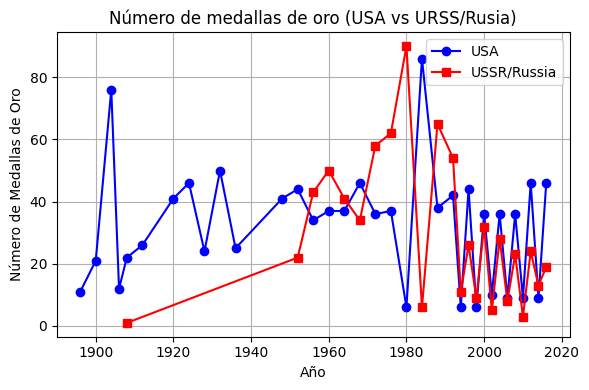

In [11]:
medallas_usa = pd.read_sql("""
    SELECT Year, COUNT(*) AS N_Medallas
    FROM (
    SELECT DISTINCT Team, Year, Event, NOC
    FROM athlete_events
    WHERE Medal = 'Gold' AND NOC = 'USA'
    )
    GROUP BY NOC, Year
    ORDER BY Year DESC
""", conn)
medallas_urss = pd.read_sql("""
    SELECT Year, COUNT(*) AS N_Medallas
    FROM (
    SELECT DISTINCT Team, Year, Event, NOC
    FROM athlete_events
    WHERE Medal = 'Gold' AND NOC IN ('URS','EUN','RUS')
    )
    GROUP BY NOC, Year
    ORDER BY Year DESC
""", conn)

plt.figure(figsize=(6,4))
plt.plot(medallas_usa['Year'], medallas_usa['N_Medallas'], marker='o', label='USA', color = 'blue')
plt.plot(medallas_urss['Year'], medallas_urss['N_Medallas'], marker='s', label='USSR/Russia', color ='red')
plt.xlabel('Año')
plt.ylabel('Número de Medallas de Oro')
plt.title('Número de medallas de oro (USA vs URSS/Rusia)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Rusia participó en los Juegos Olímpicos antes de 1912 como el Imperio ruso, pero tras la Revolución rusa dejó de competir y no volvió a los Juegos durante décadas. La Unión Soviética no participó hasta 1952, ya que durante ese tiempo rechazaba los Juegos Olímpicos por motivos políticos e ideológicos.

Tiempo después comienza la Guerra Fría, donde las dos potencias están en una batalla continua por la superioridad cultural, política, económica y tecnológica, compitiendo en ámbitos como la carrera espacial, el deporte y la influencia internacional. De esta manera la Unión Sovietica empezó con el dopaje sistemático y organizado de sus atletas. Destaca especialmente el pico soviético alrededor de 1980, seguido de una caída brusca en 1984 debido al boicot. Por su parte, Estados Unidos también muestra altibajos, con un aumento notable en 1984 al no competir la URSS.

Tras el fin de la Unión Soviética, los resultados asociados a Rusia se vuelven más irregulares y, en general, inferiores a los de la etapa soviética, reflejando el cambio político y deportivo tras la Guerra Fría.


## 4.2 Organización

Busquemos cuales son los 10 deportes con más presencia en los juegos olímpicos:

In [12]:
deporte_mas_eventos =pd.read_sql("""
    SELECT Sport, COUNT(DISTINCT Event) AS N_Eventos
    FROM athlete_events
    GROUP BY Sport
    ORDER BY N_Eventos DESC
""", conn).set_index('Sport')

In [13]:
deporte_mas_eventos.head(10)

,N_Eventos
Sport,
Shooting,83
Athletics,83
Swimming,55
Cycling,44
Sailing,38
Wrestling,30
Art Competitions,29
Archery,29
Gymnastics,27


Sorprendente la disciplina de tiro ha sido la disciplina, más continuada dentro de la organización con 83 eventos junto con atletismo. Seguidamento nos encontramos la natación (55 eventos) y el ciclismo (44 eventos).

Busquemos los años con más participantes:

In [14]:
años_con_mas_participantes =pd.read_sql("""
    SELECT Year, COUNT(DISTINCT ID) AS Participantes 
    FROM athlete_events 
    GROUP BY Year 
    ORDER BY Participantes DESC;
""", conn).set_index('Year')

In [15]:
años_con_mas_participantes.head(10)

,Participantes
Year,
1992,11183
2016,11179
2008,10899
2000,10647
2004,10557
2012,10517
1996,10339
1988,9873
1972,8122


Barcelona 1992 no fue el año con más atletas de la historia porque marcó un récord con más de 9300 participantes. Esto ocurrió principalmente porque fue la primera edición en 20 años sin boicots políticos, permitiendo el regreso de Sudáfrica tras el Apartheid, la participación de las repúblicas bálticas de forma independiente tras la caída de la URSS y el debut de una Alemania unificada, lo que convirtió a esos Juegos en el gran reencuentro del deporte mundial.

Vemos como Rio 2016 tiene prácticamente los mismos participantes, seguido de los ultimos años de los JJOO como 2000 y 2000. Esto ya nos indica que el numero de participantes va creciendo a lo largo de los años.

Grafiquemos la tabla:

<Figure size 1000x600 with 0 Axes>

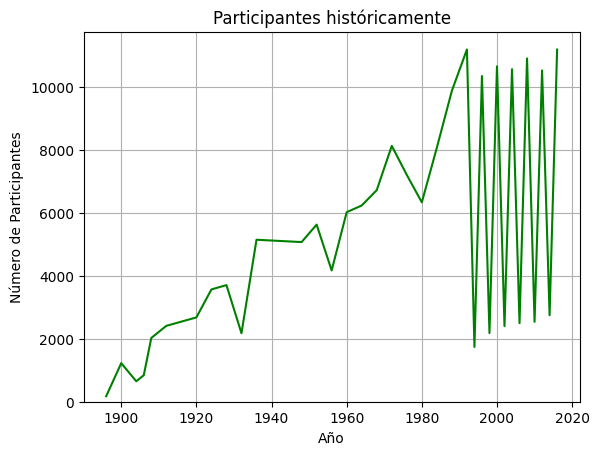

In [16]:

plt.figure(figsize=(10, 6))
ax = años_con_mas_participantes.sort_index().plot(kind='line', legend=False, color = 'green')
plt.title("Participantes históricamente")
plt.xlabel("Año")
plt.ylabel("Número de Participantes")
plt.grid(True)
ax.set_ylim(bottom=0)  # Escala del eje Y comienza en 0
plt.show()

El patrón de zig-zaf refleja el cambio de 1994 cuando los Juegos de Verano e Invierno empezaron a alternarse cada dos años, lo que genera saltos entre la masividad de uno y la menor escala del otro. Además, los huecos previos validan los datos al mostrar las cancelaciones por las Guerras Mundiales, el impacto de la Gran Depresión en 1932 y los boicots de la Guerra Fría en los 80.

Separemos el gráfico en invierno y verano:

<Figure size 400x400 with 0 Axes>

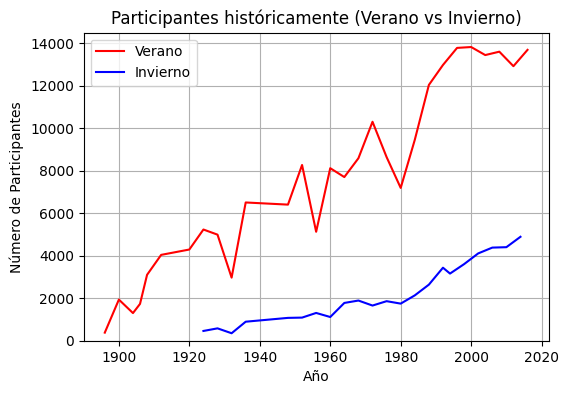

In [17]:
# Filtrar los años con más participantes solo para los Juegos de verano ('Summer')
años_con_mas_participantes_summer = pd.read_sql("""
    SELECT Year, COUNT(*) AS Participantes
    FROM athlete_events
    WHERE Season = 'Summer'
    GROUP BY Year ORDER BY COUNT(*) DESC;
""", conn).set_index('Year')

años_con_mas_participantes_winter = pd.read_sql("""
    SELECT Year, COUNT(*) AS Participantes
    FROM athlete_events
    WHERE Season = 'Winter'
    GROUP BY Year ORDER BY COUNT(*) DESC;
""", conn).set_index('Year')
# Mostrar los 10 años con más participantes de los Juegos de verano
plt.figure(figsize=(4, 4))
fig, ax = plt.subplots(figsize=(6, 4))
años_con_mas_participantes_summer.sort_index().plot(kind='line', legend=False, color='red', ax=ax, label='Verano')
años_con_mas_participantes_winter.sort_index().plot(kind='line', legend=False, color='blue', ax=ax, label='Invierno')
plt.title("Participantes históricamente (Verano vs Invierno)")
plt.xlabel("Año")
plt.ylabel("Número de Participantes")
plt.grid(True)
ax.set_ylim(bottom=0)  # Escala del eje Y comienza en 0
ax.legend(['Verano', 'Invierno'])
plt.show()

In [18]:
diferencia_verano_invierno = años_con_mas_participantes_summer / años_con_mas_participantes_winter
diferencia_verano_invierno.dropna().sort_values(by = "Year", ascending = False).head(4)

,Participantes
Year,
1992,3.776775
1988,4.561197
1984,4.430178
1980,4.118557


Este gráfico sí refleja la tendencia real del número de parrticipantes. Vemos que hay una gran diferencia entre los participantes de invierno y los de verano, más que cuatriplicando el número. Podemos observar las grandes caídas en número de atletas justo en los años de la primera y segunda guerras mundiales (Estocolmo 1912 y Alemania 1936) y los complots de los años de la guerra fría (Moscú 1980 y Los Ángeles 1984).

Veamos ahora la diferencia histórica entre hombres y mujeres:

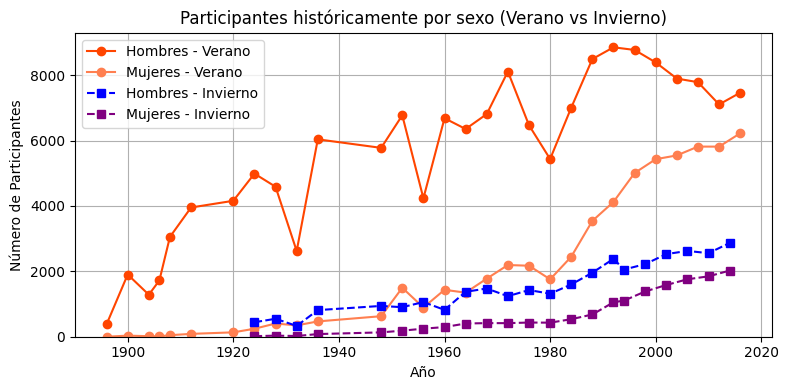

In [19]:
# Filtrar los años con más participantes para hombres y mujeres (Verano vs Invierno)
participantes_summer = pd.read_sql("""
    SELECT Year, Sex, COUNT(*) AS Participantes
    FROM athlete_events
    WHERE Season = 'Summer'
    GROUP BY Year, Sex
    ORDER BY Year ASC
""", conn)

participantes_winter = pd.read_sql("""
    SELECT Year, Sex, COUNT(*) AS Participantes
    FROM athlete_events
    WHERE Season = 'Winter'
    GROUP BY Year, Sex
    ORDER BY Year ASC
""", conn)

# Pivot para obtener separado hombres/mujeres por año
pivot_summer = participantes_summer.pivot(index='Year', columns='Sex', values='Participantes').fillna(0)
pivot_winter = participantes_winter.pivot(index='Year', columns='Sex', values='Participantes').fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
pivot_summer[['M', 'F']].plot(ax=ax, kind='line', color=['orangered', 'coral'], linestyle='-', marker='o')
pivot_winter[['M', 'F']].plot(ax=ax, kind='line', color=['blue', 'purple'], linestyle='--', marker='s')

plt.title("Participantes históricamente por sexo (Verano vs Invierno)")
plt.xlabel("Año")
plt.ylabel("Número de Participantes")
plt.grid(True)
ax.set_ylim(bottom=0)
ax.legend(['Hombres - Verano', 'Mujeres - Verano', 'Hombres - Invierno', 'Mujeres - Invierno'])
plt.tight_layout()
plt.show()

In [34]:
# Obtener por SQL la diferencia entre hombres y mujeres participantes por año (ambas temporadas)
tabla_diferencia_sql = pd.read_sql("""
    SELECT 
        Year,
        SUM(CASE WHEN Sex = 'M' THEN 1 ELSE 0 END) AS Hombres,
        SUM(CASE WHEN Sex = 'F' THEN 1 ELSE 0 END) AS Mujeres,
        COUNT(*) AS Total,
        ROUND(100.0 * SUM(CASE WHEN Sex = 'F' THEN 1 ELSE 0 END) / COUNT(*), 2) AS Porcentaje_Mujeres
    FROM athlete_events
    GROUP BY Year
    ORDER BY Year ASC
""", conn)

tabla_diferencia_sql.head(5).set_index("Year")

,Hombres,Mujeres,Total,Porcentaje_Mujeres
Year,,,,
1896,380,0,380,0.00
1900,1903,33,1936,1.70
1904,1285,16,1301,1.23
1906,1722,11,1733,0.63
1908,3054,47,3101,1.52


In [35]:
tabla_diferencia_sql.tail(5).set_index("Year")

,Hombres,Mujeres,Total,Porcentaje_Mujeres
Year,,,,
2008,7786,5816,13602,42.76
2010,2555,1847,4402,41.96
2012,7105,5815,12920,45.01
2014,2868,2023,4891,41.36
2016,7465,6223,13688,45.46


Al desglosar los datos por sexo y temporada, se evidencia que la brecha de género inicial era absoluta, con una participación masculina dominante y una participación femenina marginal durante las primeras décadas del siglo XX. Sin embargo, a partir de la década de 1980, vemos un gran punto de inflexión: mientras que el número de hombres tiende a estabilizarse, la participación de las mujeres experimenta un crecimiento exponencial acelerado, estrechando de forma constante la diferencia numérica en ambas temporadas.

Este fenómeno, visible tanto en los eventos de Verano como en los de Invierno, no solo refleja la expansión logística del movimiento olímpico, sino que documenta el éxito de las políticas de inclusión y el progreso social hacia la equidad de género en el deporte de élite mundial.

### 4.3 Caracteristicas físicas

#### 4.3.1 Edad

Vemos cuales son los deportes con mayor diferencia de edad entre medallistas:

In [22]:

deportes_diferencia = pd.read_sql("""
    SELECT Sport,
       MIN(Age) as min_edad,
       MAX(Age) as max_edad,
       MAX(Age) - MIN(Age) as Diferencia
    FROM athlete_events
    WHERE Medal != 'NA'
    AND Sport IN (
    SELECT Sport FROM athlete_events GROUP BY Sport HAVING COUNT(*) > 10
    )
    GROUP BY Sport
    HAVING max_edad != 'NA'
    ORDER BY Diferencia DESC
""", conn)

deportes_diferencia.set_index("Sport").head(10)

,min_edad,max_edad,Diferencia
Sport,,,
Croquet,15,58,43
Curling,22,58,36
Golf,17,50,33
Ice Hockey,15,43,28
Canoeing,15,43,28
Racquets,19,45,26
Ski Jumping,16,41,25
Luge,17,42,25
Handball,17,42,25


Observamos como los deportes en los que hay más diferencia són los relacionados a la puntería como el croquet, curling y golf, donde el talento y la práctica destaca más que los atributos físicos de los participantes.

Sorpendentemente también nos encontramos el Ice Hockey. Este fenómeno se explica por su naturaleza de deporte colectivo: al darse las medallas de oro a toda la plantilla, el registro contabiliza una mayor diversidad de roles y veteranía dentro de un mismo equipo, a diferencia de las disciplinas individuales donde el biotipo suele ser mucho más restringido y específico.

Veamos los deportes con menos diferencia de edad:

In [23]:
deportes_diferencia.set_index("Sport").sort_values(by='Diferencia', ascending=True).head(10)

,min_edad,max_edad,Diferencia
Sport,,,
Rhythmic Gymnastics,15,25,10
Military Ski Patrol,20,32,12
Triathlon,22,35,13
Rugby Sevens,19,32,13
Synchronized Swimming,16,31,15
Taekwondo,17,32,15
Freestyle Skiing,18,34,16
Trampolining,18,34,16
Badminton,16,34,18


Vemos como La gimnasia rítmica es la disciplina con menos diferencia de edad. Esto debido a la gran flexibilidad requerida, atributo que fisiológicamente se pierde a lo largo de los años.

Le sigue patrulla militar con una diferencia de 12 años de edad. Este es un deporte de equipo de invierno, en el que los deportistas compiten en una mezcla de esquí de fondo y esquí de travesía así como tiro. Es un antecedente del actual biatlón. Las competiciones de patrulla militar se componen de 25 kilómetros de esquí de fondo y tiro.

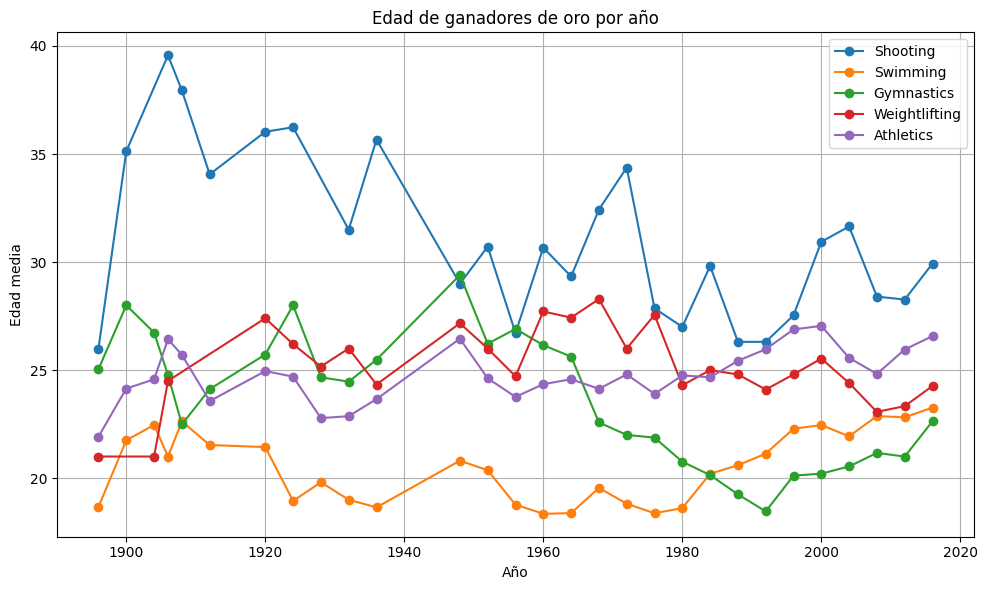

In [29]:
# Gráfico de la edad media de ganadores de oro por año en ciertos deportes

deportes = ["Shooting", "Swimming", "Gymnastics", "Weightlifting", "Athletics"]

# Obtener los datos de los ganadores de oro en los deportes seleccionados
edad_oro_deportes = pd.read_sql(f"""
    SELECT Sport, Year, Age
    FROM athlete_events
    WHERE Medal='Gold'
      AND Sport IN ({','.join(["'{}'".format(deporte) for deporte in deportes])})
      AND Age != 'NA'
""", conn)

# Convertir la edad a numérico por si acaso
edad_oro_deportes['Age'] = pd.to_numeric(edad_oro_deportes['Age'], errors='coerce')
edad_oro_deportes = edad_oro_deportes.dropna(subset=["Age"])

# Calcular la edad de los ganadores de oro por deporte y año
edad_media_ano = edad_oro_deportes.groupby(['Sport', 'Year'])['Age'].mean().reset_index()

plt.figure(figsize=(10,6))
for deporte in deportes:
    datos = edad_media_ano[edad_media_ano['Sport'] == deporte]
    plt.plot(datos['Year'], datos['Age'], marker='o', label=deporte)

plt.title("Edad de ganadores de oro por año")
plt.xlabel("Año")
plt.ylabel("Edad media")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Vemos en estos deportes que la edad ideal para ganar suele rondar entre los 18 y 30 años. Observamos en el caso de los deportes de tiro que las edades suelen ser superiores a disciplinas donde el físico es el factor determinante, como la potencia explosiva o la flexibilidad extrema.

A diferencia de la gimnasia o el atletismo de velocidad, el tiro deportivo prioriza la estabilidad de precisión, el control mental y la experiencia acumulada, cualidades que no se deterioran tan rápido con la edad e incluso suelen madurar con el tiempo.

#### 4.3.2 Pesos y Alturas

Ordenaremos los deportes por Indice de Masa Corporal (IMC):

In [25]:
# Obtener la media de IMC por deporte (IMC = peso en kg / (altura en metros)^2)

media_imc_por_deporte = pd.read_sql("""
    SELECT 
        Sport, 
        AVG(CAST(Weight AS FLOAT) / POWER(CAST(Height AS FLOAT)/100, 2)) AS IMC_Medio
    FROM athlete_events
    WHERE Weight != 'NA' AND Height != 'NA'
    GROUP BY Sport
""", conn).round(1)

media_imc_por_deporte = media_imc_por_deporte.reset_index(drop=True)
media_imc_por_deporte.sort_values("IMC_Medio", ascending=True).set_index("Sport").head(10)

,IMC_Medio
Sport,
Rhythmic Gymnastics,17.3
Synchronized Swimming,19.7
Triathlon,20.4
Figure Skating,20.8
Ski Jumping,20.9
Gymnastics,21.3
Trampolining,21.3
Nordic Combined,21.5
Taekwondo,21.6


La gimnasia rítmica es la disciplina con menos IMC medio con 17.3 puntos. Esto se debe a que tanto la grasa como el músculo impide la flexibilidad, característica principal de la modalidad. A parte de ser un deporte donde predominan las mujeres, en general teniendo un IMC más bajo que los hombres.

Le sigue natación sincronizada con 19.7 puntos. Al igual que la gimnasia rítmica, en esta disciplina predominan principalmente las mujeres.

El tercer deporte con menos IMC encontramos al Triatlón. Deporte de fondo extremo donde no es necesaria la fuerza explosiva, por lo que el exceso de masa muscular se convierte en una carga energética innecesaria.

In [26]:
media_imc_por_deporte.sort_values("IMC_Medio", ascending=False).set_index("Sport").head(10)

,IMC_Medio
Sport,
Weightlifting,27.7
Tug-Of-War,27.5
Bobsleigh,27.0
Baseball,25.7
Rugby,25.7
Judo,25.6
Rugby Sevens,25.5
Art Competitions,25.1
Ice Hockey,25.1


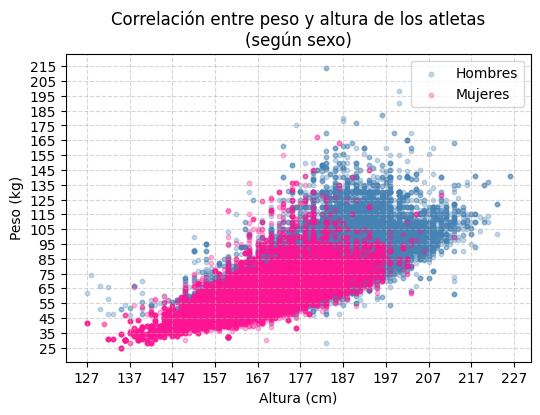

In [31]:
# Gráfico de correlación entre peso y altura de atletas, con intervalos (bins) más altos

# Seleccionar los datos válidos
athlete_wh = pd.read_sql("""
    SELECT Height, Weight, Sex
    FROM athlete_events
    WHERE Height IS NOT NULL AND Weight IS NOT NULL AND Sex IS NOT NULL
""", conn)

# Convertir columnas a numérico y filtrar posibles valores no convertibles
athlete_wh['Height'] = pd.to_numeric(athlete_wh['Height'], errors='coerce')
athlete_wh['Weight'] = pd.to_numeric(athlete_wh['Weight'], errors='coerce')
athlete_wh = athlete_wh.dropna(subset=['Height', 'Weight', 'Sex'])

# Definir bins más grandes para los ejes
altura_bins = range(int(athlete_wh['Height'].min()), int(athlete_wh['Height'].max()) + 10, 10)
peso_bins = range(int(athlete_wh['Weight'].min()), int(athlete_wh['Weight'].max()) + 10, 10)

plt.figure(figsize=(6,4))
colors = {'M': 'steelblue', 'F': 'deeppink'}
labels = {'M': 'Hombres', 'F': 'Mujeres'}

for sex in ['M', 'F']:
    sub = athlete_wh[athlete_wh['Sex'] == sex]
    plt.scatter(
        sub['Height'], sub['Weight'], 
        alpha=0.3, s=10, c=colors[sex], label=labels[sex]
    )

plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.title('Correlación entre peso y altura de los atletas\n(según sexo)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(altura_bins)
plt.yticks(peso_bins)
plt.legend()
plt.show()

Vemos como en promedio los hombres tienden a ser más altos y pesados que las mujeres, ya que sus puntos se concentran en rangos superiores de ambas variables. Existe una zona de superposición significativa entre ambos grupos, lo que indica que hay mujeres con alturas y pesos similares a los de algunos hombres, aunque la distribución general de cada grupo mantiene diferencias claras.

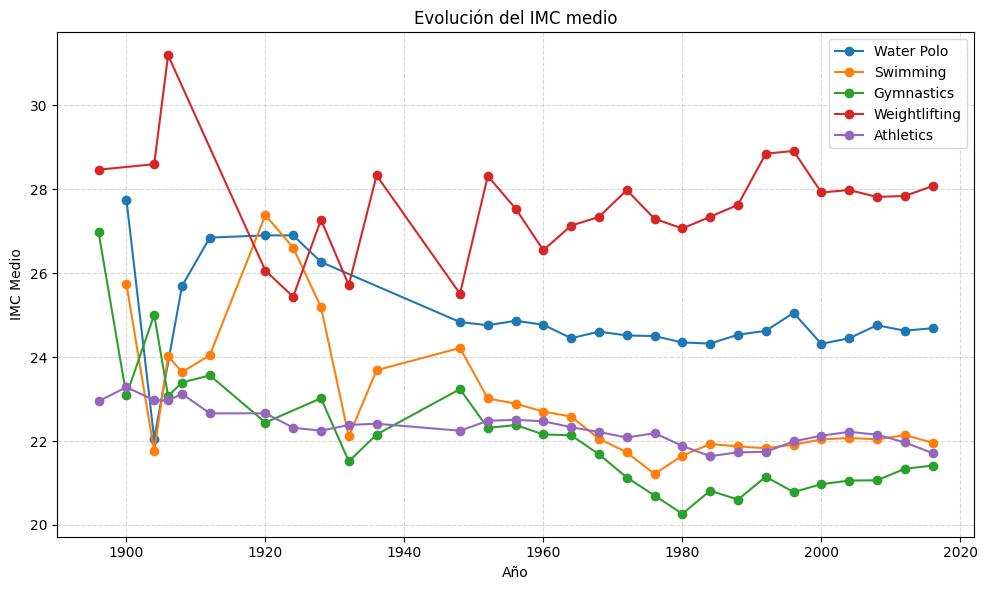

In [ ]:
# Evolución del IMC a lo largo de los años para algunos deportes seleccionados

# Definimos los deportes de interés
deportes = ["Water Polo", "Swimming", "Gymnastics", "Weightlifting", "Athletics"]

# Consulta para calcular el IMC promedio por deporte y año
imc_anual_deportes = pd.read_sql(f"""
    SELECT
        Year,
        Sport,
        AVG(CAST(Weight AS FLOAT) / POWER(CAST(Height AS FLOAT)/100, 2)) AS IMC_Medio
    FROM athlete_events
    WHERE
        Weight != 'NA'
        AND Height != 'NA'
        AND Sport IN ({','.join(['?']*len(deportes))})
    GROUP BY Year, Sport
    ORDER BY Year ASC, Sport
""", conn, params=deportes)

plt.figure(figsize=(10,6))
for deporte in deportes:
    deporte_data = imc_anual_deportes[imc_anual_deportes["Sport"] == deporte]
    plt.plot(deporte_data["Year"], deporte_data["IMC_Medio"], marker='o', label=deporte)

plt.title("Evolución del IMC medio")
plt.xlabel("Año")
plt.ylabel("IMC Medio")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

En el gráfico se ve como los IMC forman grandes altibajos en los primeros años de los JJOO. Con la profesionalización de la organización los pesos y alturas se van estandarizando, se ve reflejado en el gráfico como las líneas van convergiendo a índices de masa corporal más constantes.

## 5. Conclusiones

### 5.1 Desempeño deportivo

**H1 — Estados Unidos lidera históricamente**

Con 1.131 oros, Estados Unidos es el país con más medallas de oro de la historia olímpica con una ventaja aplastante sobre el segundo clasificado. La Unión Soviética, con 471 oros, confirma la hipótesis de la rivalidad histórica, aunque únicamente compitió entre 1952 y 1988. Esta lectura lo confirma el análisis por eras, la URSS dominó la Guerra Fría con 45.9 oros por edición, mientras que Estados Unidos ha sido el país más ganador en todas las demás épocas. China, tal como se hipotetizó, no aparece entre los grandes dominadores históricos pese a su relevancia actual.

**H2 — Michael Phelps como el mayor medallista**

Michael Phelps tiene 23 oros olímpicos, más del doble que el segundo clasificado (Ray Ewry, con 10). Es el medallista de oro más dominante de los 120 años de historia olímpica sin ningún competidor cercano.

**H3 — El ratio de victoria premia la especialización, no el tamaño**

La Unión Soviética encabeza esta métrica con un 28%, seguida de la Alemania del Este con un 21.8%. Esto sugiere que los programas olímpicos de estado de la Guerra Fría, más selectivos y centralizados, eran más eficientes por atleta que el modelo norteamericano, que envía un volumen mucho mayor de participantes.

### 5.2 Organización

El tiro y el atletismo son los deportes con más eventos en la historia olímpica (83 cada uno), lo que refleja su carácter fundacional en los Juegos. La participación global ha crecido de forma sostenida desde los 380 atletas de Atenas 1896 hasta los más de 11.000 de Barcelona 1992 y Río 2016, con interrupciones que validan los datos: cancelaciones por guerras mundiales y caídas por los boicots de la Guerra Fría.

La evolución de la presencia de las mujeres en los JJOO es el hallazgo más significativo: en 1896 la participación femenina era cero. En 2016, las mujeres representaban el 45.5% del total (6.223 de 13.688 atletas). Este crecimiento no ha sido lineal sino acelerado a partir de los años 80.

### 5.3 Características físicas

**H4 — Especialización física creciente**

El análisis del IMC por deporte confirma una especialización física extrema según la disciplina: la gimnasia rítmica presenta el IMC más bajo (17.3), mientras que la halterofilia y el tiro a la cuerda alcanzan el más alto (27.7 y 27.5). La evolución temporal del IMC muestra que en los primeros años del siglo XX los valores eran muy irregulares, pero a partir de los años 80 convergen hacia rangos más estables por deporte, lo que apunta a una selección física cada vez más sistemática y especializada.

Respecto a la edad, los deportes de precisión como el tiro o el golf permiten carreras más largas (diferencias de hasta 43 años entre medallistas), mientras que deportes de alta exigencia física como la gimnasia rítmica concentran sus medallistas en una ventana de apenas 10 años (15–25). La edad óptima de victoria se sitúa generalmente entre los 18 y los 30 años, con variaciones significativas según la disciplina.

### 5.4 Limitaciones del análisis

- El dataset cubre hasta Río 2016, por lo que no incluye Tokio 2020 ni París 2024.
- El sobreconteo en deportes de equipo ha sido mitigado usando `DISTINCT` en las queries de medallas, pero puede persistir en algunos análisis secundarios.
- Los datos de peso y altura tienen valores nulos significativos, especialmente en ediciones anteriores a 1960, lo que puede sesgar los promedios físicos hacia atletas más recientes.